# 02 — Exploratory Data Analysis

**Goal:** understand *who churns* before modelling. Every plot answers a
business question, and each finding either motivates a feature or an
expectation we can later sanity-check against the model's learned importances.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [2]:
from src.data_loader import load_data
from src.preprocessing import clean_raw_data
from src.utils import load_config

config = load_config()
df = clean_raw_data(load_data(str(ROOT / config["data"]["raw_path"])), config)
df["churn"] = df["churn_value"].map({0: "Stayed", 1: "Churned"})
df.head(3)

2026-07-31 09:39:27,890 | src.preprocessing | INFO | Cleaned data: 7043 rows, 20 columns


,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Churned
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,Churned
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,Churned


## Churn rate by contract, internet service and payment method

Contract type is the strongest single signal in this dataset: month-to-month
customers can leave at any time, while contracts create switching friction.

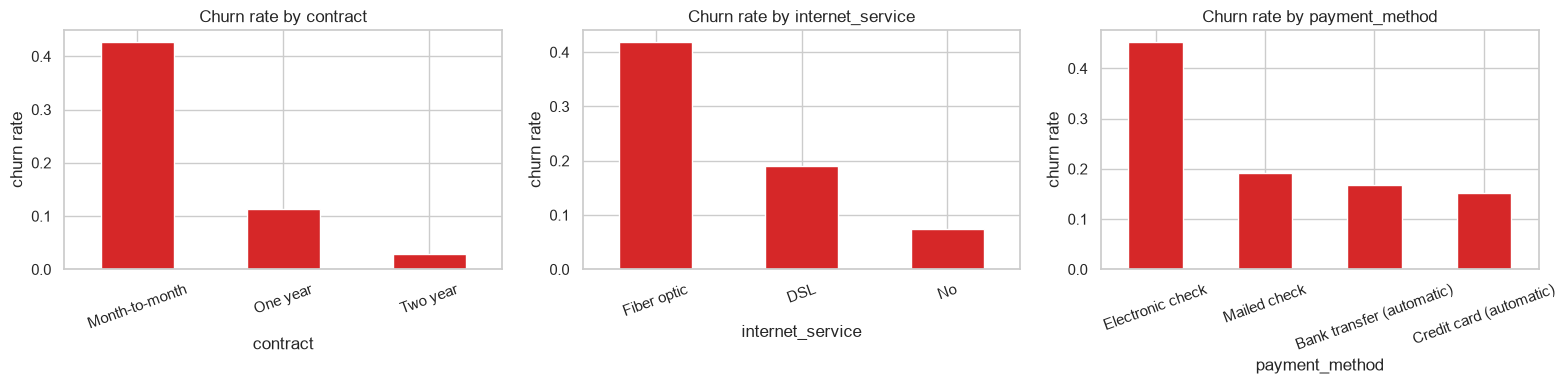

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["contract", "internet_service", "payment_method"]):
    rates = df.groupby(col, observed=True)["churn_value"].mean().sort_values(ascending=False)
    rates.plot.bar(ax=ax, color="tab:red", rot=20)
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("churn rate")
fig.tight_layout()
fig.savefig(ROOT / "reports/images/churn_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## Tenure and monthly charges

New customers churn the most (the classic "early-life churn" pattern), and
churners skew toward **higher monthly bills** — expensive fiber plans without
long contracts are the classic at-risk profile.

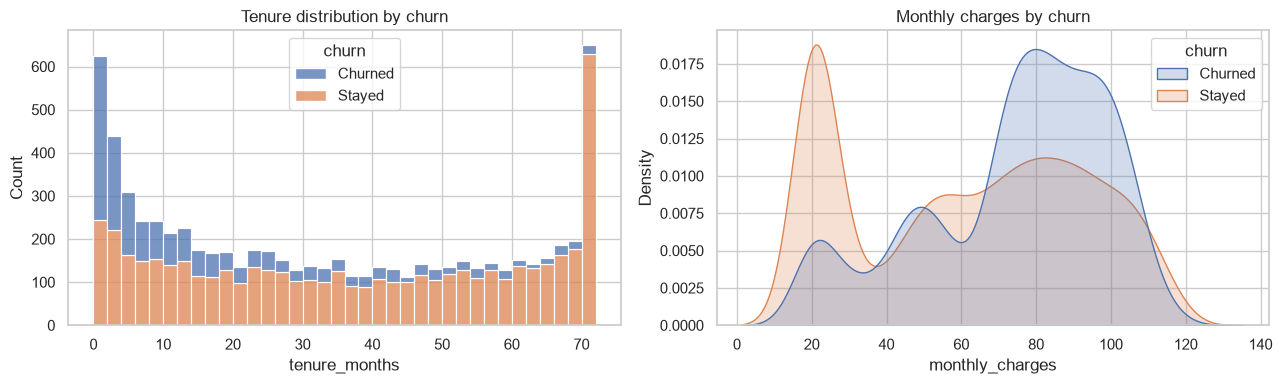

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df, x="tenure_months", hue="churn", bins=36, multiple="stack", ax=axes[0])
axes[0].set_title("Tenure distribution by churn")
sns.kdeplot(data=df, x="monthly_charges", hue="churn", fill=True, common_norm=False, ax=axes[1])
axes[1].set_title("Monthly charges by churn")
fig.tight_layout()
fig.savefig(ROOT / "reports/images/tenure_charges.png", dpi=150, bbox_inches="tight")
plt.show()

## Demographics and support services

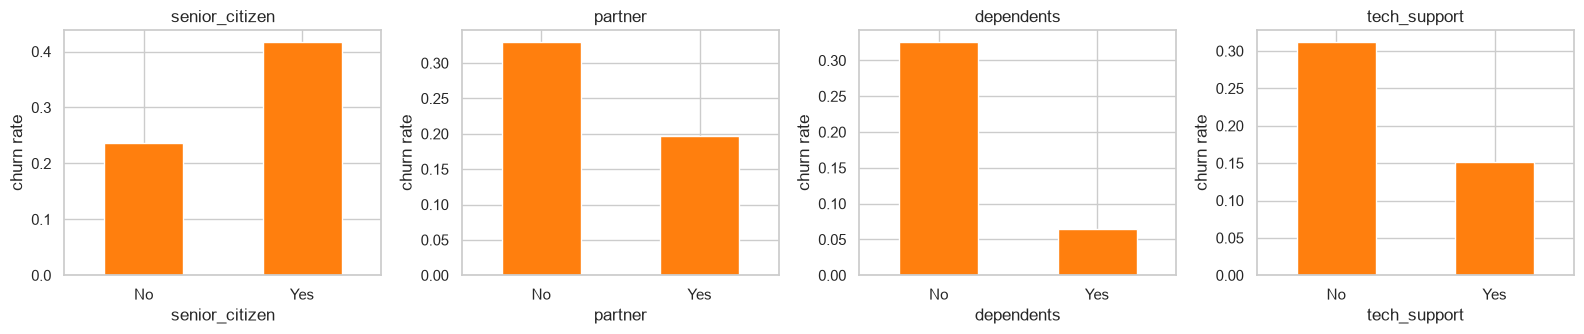

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, ["senior_citizen", "partner", "dependents", "tech_support"]):
    rates = df.groupby(col, observed=True)["churn_value"].mean()
    rates.plot.bar(ax=ax, color="tab:orange", rot=0)
    ax.set_title(col)
    ax.set_ylabel("churn rate")
fig.tight_layout()
plt.show()

## Numeric correlations

`total_charges` is almost a deterministic function of
`tenure_months × monthly_charges` — near-perfect collinearity. We keep it
anyway: trees are unaffected, and the logistic model is regularised. The
engineered features in the next notebook squeeze extra signal out of this
relationship instead of discarding it.

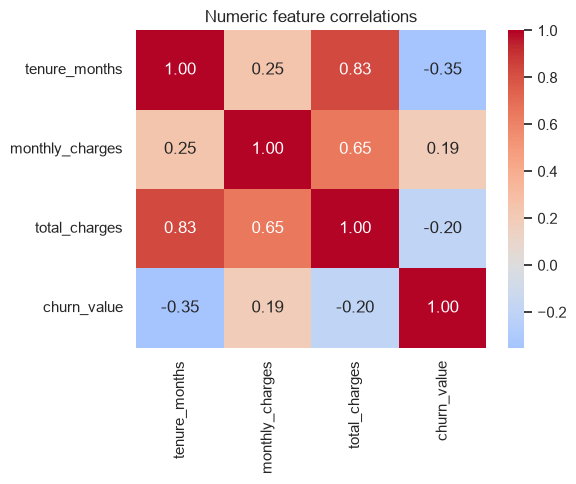

In [6]:
numeric = df.select_dtypes("number")
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric feature correlations")
fig.tight_layout()
plt.show()

## EDA findings → modelling decisions

1. **Month-to-month contract, fiber optic internet, electronic check** — the
   highest-churn segments; expect these to top feature importance.
2. **Early-life churn dominates** → engineered `tenure_bucket` gives linear
   models the non-linearity for free.
3. **Higher bills → more churn** → keep both raw charges and engineered
   `avg_monthly_spend` / `charge_growth`.
4. **Protective services** (tech support, online security) correlate with
   staying → engineered `num_addon_services` counts ecosystem lock-in.
5. **~26.5% positive class** → class weighting + recall-oriented threshold
   tuning rather than accuracy.